### 6. DECISION TREES AND ENSENBLE LEARNING

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv('data/CreditScoring.csv', sep=',')

In [2]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head(3).T

,0,1,2
status,1,1,2
seniority,9,17,10
home,1,1,2
time,60,60,36
age,30,58,46
marital,2,3,2
records,1,1,2
job,3,1,3
expenses,73,48,90
income,129,131,200


#### RE-ENCODING THE CATEGORICAL VARIABLES

To handle the categorical variables, we need to address a few important considerations. The R file in the repository provides insights into preprocessing this data.

Here are the key points:

1. Categorical Variable Information: The R file also offers information about the categorical variables. For example:

- ‘Status’ is encoded as ‘good’ (1) and ‘bad’ (2).
- ‘Home’ includes categories like ‘rent,’ ‘owner,’ ‘priv,’ ‘ignore,’ ‘parents,’ and ‘other.’
- ‘Marital’ encompasses ‘single,’ ‘married,’ ‘widow,’ ‘separated,’ and ‘divorced.’
- ‘Records’ has ‘yes’ and ‘no.’
- ‘Job’ includes ‘fixed,’ ‘partime,’ ‘freelance,’ and ‘other.’

2. Missing Values: The missing values are encoded as a series of nines (99999999). We’ll need to address how to handle these missing values.


To proceed, we’ll need to translate these numerical values back into their respective categorical strings. This ensures our data is more interpretable and ready for analysis.

In [3]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df['status'] = df['status'].map(status_values)
df['home'] = df['home'].map(home_values)
df['marital'] = df['marital'].map(marital_values)
df['records'] = df['records'].map(records_values)
df['job'] = df['job'].map(job_values)

In [4]:
df.describe().round().T
# 99999999.0 is a placeholder for missing values in the dataset.
# We will replace it with NaN for better handling of missing data.

,count,mean,std,min,25%,50%,75%,max
seniority,4455.0,8.0,8.0,0.0,2.0,5.0,12.0,48.0
time,4455.0,46.0,15.0,6.0,36.0,48.0,60.0,72.0
age,4455.0,37.0,11.0,18.0,28.0,36.0,45.0,68.0
expenses,4455.0,56.0,20.0,35.0,35.0,51.0,72.0,180.0
income,4455.0,763317.0,8703625.0,0.0,80.0,120.0,166.0,99999999.0
assets,4455.0,1060341.0,10217569.0,0.0,0.0,3500.0,6000.0,99999999.0
debt,4455.0,404382.0,6344253.0,0.0,0.0,0.0,0.0,99999999.0
amount,4455.0,1039.0,475.0,100.0,700.0,1000.0,1300.0,5000.0
price,4455.0,1463.0,628.0,105.0,1118.0,1400.0,1692.0,11140.0


In [5]:
# handling with missing values
replace_values = ['income', 'assets', 'debt']

for col in replace_values:
    df[col] = df[col].replace(99999999.0, np.nan)

# handling with unknown values
# only one row has 'unk' in the 'status' column,
# so we can safely remove it from the dataset.
df = df[df['status'] != 'unk'].reset_index(drop=True)

#### PERFORMING THE DATA SPLIT

In [6]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

df_full_train.reset_index(drop=True)
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

y_full_train = (df_full_train['status'] == 'default').astype(int).values
y_train = (df_train['status'] == 'default').astype(int).values
y_val = (df_val['status'] == 'default').astype(int).values
y_test = (df_test['status'] == 'default').astype(int).values

X_full_train = df_full_train.drop(columns=['status'])
X_train = df_train.drop(columns=['status'])
X_val = df_val.drop(columns=['status'])
X_test = df_test.drop(columns=['status'])



#### DECISION TREES

Decision trees are a fundamental machine learning technique used for both classification and regression tasks. Their structure mirrors a flowchart: each internal node represents a feature, each branch a decision rule, and each leaf node a final prediction.

What makes decision trees stand out is their interpretability - unlike many ML models, the logic behind a prediction can be read and understood by humans, making them especially useful when explainability matters.

#### HOW A DECISION TREE IS STRUCTURED

A decision tree is made up of nodes connected by branches. Each node tests a condition on a feature - the result is either true (right branch) or false (left branch). This continues recursively until the tree reaches a leaf node, which holds the final prediction: OK or DEFAULT.

Each path from root to leaf represents a decision rule the model has learned from training data. The deeper the tree, the more specific the rules - though very deep trees risk overfitting.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

# ## Now we need to turn our training dataframe into a list of dictionaries
# ## then turn this list of dictionaries into the feature matrix. After that we train the model.

train_dict = X_train.fillna(0).to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

val_dict = X_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dict)

In [8]:
visualize = pd.DataFrame(X_train, columns=dv.get_feature_names_out().tolist())
visualize.head()

,age,amount,assets,debt,expenses,home=ignore,home=other,home=owner,home=parents,home=private,...,marital=married,marital=separated,marital=single,marital=unk,marital=widow,price,records=no,records=yes,seniority,time
0,36.0,1000.0,10000.0,0.0,75.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1400.0,1.0,0.0,10.0,36.0
1,32.0,1100.0,0.0,0.0,35.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1330.0,0.0,1.0,6.0,48.0
2,40.0,1320.0,0.0,0.0,75.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1600.0,1.0,0.0,1.0,48.0
3,23.0,1078.0,0.0,0.0,35.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1079.0,1.0,0.0,1.0,48.0
4,46.0,1100.0,4000.0,0.0,60.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1897.0,1.0,0.0,5.0,36.0


In [9]:
max_depth = [2, 3, 4, 5, 10, None]

for max_depth in max_depth:
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=11)
    tree.fit(X_train, y_train)

    # Validação
    y_pred_val = tree.predict_proba(X_val)[:, 1]
    print(f'max_depth: {max_depth}, ROC_AUC val:   {roc_auc_score(y_val, y_pred_val) * 100:.3f}%')

    # Treino (para checar overfitting)
    y_pred_train = tree.predict_proba(X_train)[:, 1]
    print(f'max_depth: {max_depth}, ROC_AUC train: {roc_auc_score(y_train, y_pred_train) * 100:.3f}%')

    print('---')

max_depth: 2, ROC_AUC val:   66.853%
max_depth: 2, ROC_AUC train: 70.550%
---
max_depth: 3, ROC_AUC val:   73.891%
max_depth: 3, ROC_AUC train: 77.610%
---
max_depth: 4, ROC_AUC val:   76.128%
max_depth: 4, ROC_AUC train: 81.643%
---
max_depth: 5, ROC_AUC val:   76.650%
max_depth: 5, ROC_AUC train: 84.338%
---
max_depth: 10, ROC_AUC val:   69.037%
max_depth: 10, ROC_AUC train: 96.385%
---
max_depth: None, ROC_AUC val:   66.386%
max_depth: None, ROC_AUC train: 100.000%
---


#### Overfitting

Looking at the validation results alone, `max_depth=5` gives the best AUC score of `76.650%` - but compare it with the training score of `84.338%`. That gap is a **warning sign**.

When we let the tree grow freely (max_depth=None), the validation AUC drops to `66.386%` while the training AUC hits a perfect `100%`. This is a textbook case of **overfitting**: the model simply memorizes every single training example, including its noise, and creates rules so specific that they are useless for any new, unseen data. It fails to generalize.

The deeper the tree, the more specific the rules - and the wider the gap between train and validation performance:

| max_depth  | ROC-AUC VAL | ROC-AUC TRAIN |    GAP     |
|:----------:|:-----------:|:-------------:|:----------:|
|      2     |    66.853%  |    70.550%    |    3.7pp   |
|      3     |    73.891%  |    77.610%    |    3.7pp   |
|      4     |    76.128%  |    81.643%    |    5.5pp   |
|      5     |    76.650%  |    84.338%    |    7.7pp   |
|     10     |    69.037%  |    96.385%    |   27.3pp   |
|    None    |    66.386%  |   100.000%    |   33.6pp   |

**By restricting the tree depth, we force it to learn broader**, `more generalizable` rules. `max_depth=5` strikes the best balance here, but it's worth tuning further - for instance by also controlling min_samples_leaf - to reduce that train/val gap without sacrificing too much validation performance.

#### DECISION STUMP

A **Decision Stump** is a decision tree with a depth of exactly 1 - meaning it makes a single split based on one feature and immediately produces a prediction. It's the most minimal form a decision tree can take: one question, two answers, done.

Despite its simplicity, the stump is far from useless. It's a foundational building block in ensemble methods like AdaBoost, where many weak learners (stumps) are combined to form a strong classifier.

---

#### FROM A STUMP TO A REAL TREE

To understand a stump, it helps to contrast it with a deeper tree. Consider the credit risk model below, trained with **`max_depth=3`** :

In [10]:
from sklearn.tree import export_text

tree = DecisionTreeClassifier(max_depth=3, random_state=11)
tree.fit(X_train, y_train)
# y_pred = tree.predict_proba(X_val)[:, 1]

feature_names = dv.get_feature_names_out().tolist()
print(export_text(tree, feature_names=feature_names))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0



**The root node asks: `"Does this person have no negative records?"`** - that's exactly what a stump would be. It splits the entire dataset into two groups based on that single feature and stops there.

But at max_**`depth=3`**, the tree goes further. Each branch refines the prediction using additional features like seniority, income, amount, and assets. **The model now captures interactions** - for example, a person with no negative records is still considered risky if their seniority is low and their requested amount is high.

|   Depth       | Name           | Behavior                           |
|---------------|----------------|------------------------------------|
|     1         | Decision Stump | One split, very high bias          |
|    2–5        | Shallow tree   | Captures some interactions         |
| Unconstrained | Full tree      | Low bias, high variance (overfits) |

#### DECISION TREE LEARNING ALGORITHM

#### KEY CONCEPTS

- **Decision Stump**: a decision tree with only one level (one condition node + leaves).
- **Split**: a condition of the form `FEATURE > T`, separating records into `LEFT` (False) and `RIGHT` (True).
- **Leaf / Decision Node**: the endpoint where we assign the most frequent class label.
- **Impurity**: how mixed a leaf is. Lower impurity = better split.
- **Misclassification Rate**: fraction of wrongly predicted records in a group = one way to measure impurity.

In [11]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df = pd.DataFrame(data, columns=['assets', 'status'])
df.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


#### FINDING THE BEST THRESHOLD 'T'

For each candidate threshold `T`, we split the dataset:
- `LEFT`  > `assets <= T`
- `RIGHT` > `assets > T`

Then we measure the **misclassification rate** on each side and compute the average.

In [12]:
def misclassification_rate(series):
    """
    Calculate the misclassification rate of a group of labels.

    This measures how "impure" a node is: if we always predict the majority
    class for every record in this group, what fraction would we get wrong?

    Example:
        Group = [default, default, default, ok]
        Majority class = 'default' (75%)
        Misclassification rate = 1 - 0.75 = 0.25 (25% error)

    Parameters
    ----------
    series : pd.Series
        A Series containing class labels (e.g. 'ok', 'default').

    Returns
    -------
    float
        Fraction of records that would be misclassified (0.0 = pure group).
    """
    # Edge case: empty group has no error
    if len(series) == 0:
        return 0.0

    # Get the proportion of each class label (e.g. default: 0.75, ok: 0.25)
    counts = series.value_counts(normalize=True)

    # The majority class is the first entry (value_counts sorts descending).
    # Error = everything that is NOT the majority class.
    return 1 - counts.iloc[0]


# Candidate thresholds 
# These are the unique asset values we'll test as split points.
# We skip the min (0) and max (9000) since they would leave one side empty.
Ts = [0, 2000, 3000, 4000, 5000, 8000]

results = []  # Will hold one dict of metrics per threshold

# Evaluate every threshold
for T in Ts:

    # Split the dataset into two groups based on the threshold:
    #   LEFT  > records where assets <= T  (condition is FALSE: "not > T")
    #   RIGHT > records where assets >  T  (condition is TRUE)
    left  = df[df.assets <= T]['status']
    right = df[df.assets >  T]['status']

    # Measure how impure (mixed) each group is
    imp_left  = misclassification_rate(left)
    imp_right = misclassification_rate(right)

    n = len(df)  # Total number of records in the dataset

    # Weighted average impurity:
    # Groups of different sizes should contribute proportionally.
    # A large pure group is better than a small pure group.
    avg = (len(left) * imp_left + len(right) * imp_right) / n

    # Store results for this threshold
    results.append({
        'T': T,

        # At each leaf, the tree makes a prediction by looking at all the training
        # records that landed in that group and picking the most common class label.
        # This is called the "majority vote" rule.
        #
        # pd.Series.mode() returns all values that appear most frequently.
        # We take [0] to get a single label even if there's a tie.
        #
        # Example - LEFT group for T=4000:
        #   assets  status
        #   2000    default   ← default
        #   0       default   ← default
        #   4000    ok        ← ok
        #   3000    default   ← default
        #
        #   mode() → ['default']   (appears 3 out of 4 times)
        #   Decision LEFT = 'default'
        #
        # If the group happens to be empty (e.g. T=0 produces an empty LEFT),
        # we fall back to '-' to avoid an IndexError on mode()[0].
        'Decision LEFT':  left.mode()[0]  if len(left)  else '-',
        'Decision RIGHT': right.mode()[0] if len(right) else '-',

        # Impurity formatted as a percentage for readability
        'Impurity LEFT':  f"{imp_left:.0%}",
        'Impurity RIGHT': f"{imp_right:.0%}",

        # The metric we minimise to find the best split
        'AVG Impurity':   f"{avg:.0%}",
    })

# Display results
# The row with the lowest AVG Impurity is the best threshold to use.
pd.DataFrame(results).set_index('T')

,Decision LEFT,Decision RIGHT,Impurity LEFT,Impurity RIGHT,AVG Impurity
T,,,,,
0,default,ok,0%,43%,38%
2000,default,ok,0%,33%,25%
3000,default,ok,0%,20%,12%
4000,default,ok,25%,25%,25%
5000,default,default,50%,50%,50%
8000,default,ok,43%,0%,38%


#### RESULT

The threshold **T = 3000** gives the lowest average impurity (**12%**), so it is the best split.

```
ASSETS > 3000
   /        \
FALSE       TRUE
DEFAULT      OK
```

#### SUMMARY: HOW THE ALGORITHM WORKS

1. Sort the dataset by the feature.
2. Identify all candidate thresholds (unique values).
3. For each threshold, split into LEFT and RIGHT.
4. Compute impurity (e.g. misclassification rate) for each side.
5. Compute weighted average impurity.
6. Pick the threshold with the **lowest** average impurity.

---

**Other impurity criteria** (available in scikit-learn): `gini`, `entropy`. Same idea, different formula.

#### DECISION TREES PARAMETER TUNING

In [28]:
md = [4, 5, 6, 7, 10, 15, 20, None]
msl = [1, 2, 5, 10, 15, 20, 100, 200, 500]
scores = []

for max_depth in md:
    for samples_leaf in msl:
        tree = DecisionTreeClassifier(max_depth=max_depth,
                                      min_samples_leaf=samples_leaf)

        tree.fit(X_train, y_train)

        y_pred = tree.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred) * 100
        
        scores.append((max_depth, samples_leaf, auc))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores = df_scores.sort_values('auc', ascending=False).reset_index(drop=True)

<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

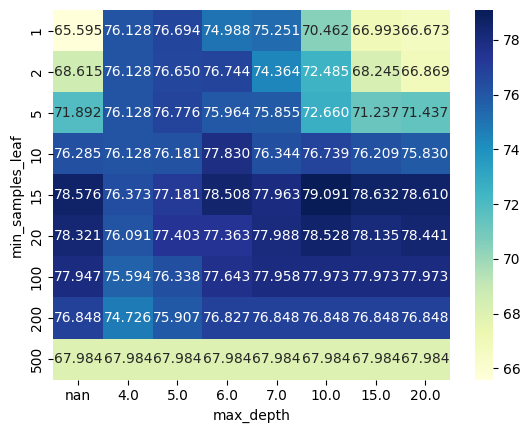

In [32]:
scores_pivot = df_scores.pivot(index='min_samples_leaf',
                columns='max_depth',
                values='auc').round(3)

sns.heatmap(scores_pivot, annot=True, fmt='.3f', cmap='YlGnBu')

In [33]:
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current